# Traditional Machine Learning Models

This notebook focuses on developing and evaluating traditional machine learning models for predicting age-related medical conditions using anonymized biomedical data.

### Objectives
- Build baseline and traditional ML models
- Compare model performance using appropriate metrics
- Analyze strengths and limitations of each approach

### Models Covered
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest

In [21]:
#DataSet Loader and extracts the zip

import os 
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Data Loading

In this section, we load the dataset from the project directory. The dataset includes training, testing, and supplementary metadata files.

We use a flexible path setup to ensure the notebook runs correctly regardless of the working directory.

In [22]:
# Data loading
from pathlib import Path
import pandas as pd

REQUIRED = ["train.csv", "test.csv", "greeks.csv"]
OPTIONAL = ["sample_submission.csv"]

def find_dataset_folder():
    current_dir = Path.cwd().resolve()

    possible_folders = [
        current_dir / "../Data",   # notebook inside Notebooks/
        current_dir / "Data",      # fallback if notebook run from project root
        current_dir.parent / "Data",
        current_dir
    ]

    for folder in possible_folders:
        folder = folder.resolve()
        if folder.exists() and all((folder / file).exists() for file in REQUIRED):
            return folder

    raise FileNotFoundError(
        "Could not find dataset folder. Expected train.csv, test.csv, and greeks.csv in the Data folder."
    )

DATA_DIR = find_dataset_folder()

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
greeks = pd.read_csv(DATA_DIR / "greeks.csv")

sample_submission_path = DATA_DIR / "sample_submission.csv"
if sample_submission_path.exists():
    sample_submission = pd.read_csv(sample_submission_path)
else:
    sample_submission = None
    print("sample_submission.csv not found yet. Continuing without it.")

print("DATA_DIR:", DATA_DIR)
print("\nDataset Shapes:")
print("train:", train.shape)
print("test:", test.shape)
print("greeks:", greeks.shape)
if sample_submission is not None:
    print("sample_submission:", sample_submission.shape)

train.head()

sample_submission.csv not found yet. Continuing without it.
DATA_DIR: C:\Users\miran\Documents\GitHub\CS4662-Project-Identifying-Age-Related-Conditions\Data

Dataset Shapes:
train: (617, 58)
test: (5, 57)
greeks: (617, 6)


,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1


## Data Preprocessing

Before training models, we prepare the dataset by handling missing values, scaling features, and ensuring consistency across training and validation data.

These steps are critical to ensure fair model comparison and stable performance.

In [23]:
#Checks the Dataset for examples of Class 0 and 1
#Assists in prediction for the model's accuracy
#Data Check of class balance, missing values and feature types

print("Target Distribution:")
print(train["Class"].value_counts())
print()

print("Target Disribution Percentage:")
print(train["Class"].value_counts(normalize=True))
print()

print("Feature Data Types:")

print(train.dtypes.value_counts())
print()

missing_values = train.isna().sum().sort_values(ascending=False)
print("Top Missing Value Columns:")
print(missing_values[missing_values > 0].head(15))

Target Distribution:
Class
0    509
1    108
Name: count, dtype: int64

Target Disribution Percentage:
Class
0    0.824959
1    0.175041
Name: proportion, dtype: float64

Feature Data Types:
float64    55
object      2
int64       1
Name: count, dtype: int64

Top Missing Value Columns:
BQ    60
EL    60
CC     3
CB     2
FS     2
FC     1
DU     1
FL     1
GL     1
dtype: int64


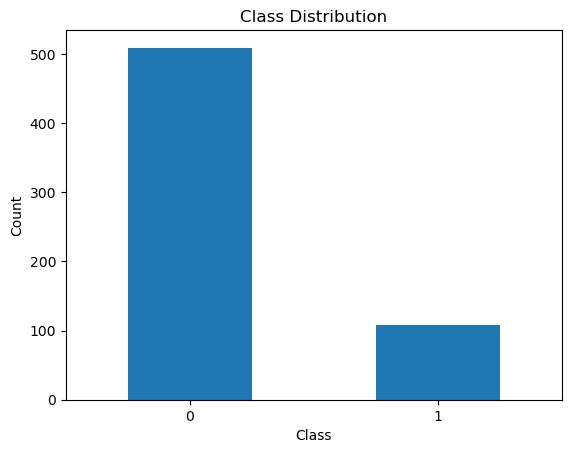

In [24]:
#Separates features and targer

train["Class"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [25]:
#Data Overivew
X = train.drop(columns=["Class"])
y = train["Class"]

test_ids = test["Id"].copy()

X_model = X.drop(columns=["Id"])
test_model = test.drop(columns=["Id"])

numeric_features = X_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_model.select_dtypes(include=["object"]).columns.tolist()

print("# of numeric features:", len(numeric_features))
print("Categorical Features:", categorical_features)

# of numeric features: 55
Categorical Features: ['EJ']


In [26]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [27]:
#Evaluating Log loss for evaluation
def balanced_log_loss(y_true, y_pred_proba):
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)

    eps = 1e-15
    y_pred_proba = np.clip(y_pred_proba, eps, 1 - eps)

    n0 = np.sum(y_true == 0)
    n1 = np.sum(y_true == 1)

    loss0 = -np.sum((y_true == 0) * np.log(y_pred_proba[:, 0])) / n0
    loss1 = -np.sum((y_true == 1) * np.log(y_pred_proba[:, 1])) / n1

    return (loss0 + loss1) / 2

def negative_balanced_log_loss_scorer(estimator, X_val, y_val):
    pred_proba = estimator.predict_proba(X_val)
    return -balanced_log_loss(y_val, pred_proba)

In [28]:
#Cross validation for balanced splits
cv = StratifiedKFold (
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [29]:
#Change this to False when wanting to run a bigger sample
#Current on True for a quick test that's all

FAST_MODE = True
print("Fast mode:", FAST_MODE)

Fast mode: True


In [30]:
def evaluate_model_cv(model_name, model, X_data, y_data, cv):
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    oof_proba = cross_val_predict(
        model,
        X_data,
        y_data,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )

    oof_pred = np.argmax(oof_proba, axis=1)

    standard_ll = log_loss(y_data, oof_proba)
    balanced_ll = balanced_log_loss(y_data, oof_proba)
    acc = accuracy_score(y_data, oof_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Log Loss: {standard_ll:.4f}")
    print(f"Balanced Log Loss: {balanced_ll:.4f}")
    print()
    print("Classifciation Report")
    print(classification_report(y_data, oof_pred))

    cm = confusion_matrix(y_data, oof_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot()
    plt.title(f"Confusion MAtrix: {model_name}")
    plt.show()

    report = classification_report(y_data, oof_pred, output_dict=True)

    return {
        "model_name": model_name,
        "accuracy": acc,
        "log_loss": standard_ll,
        "balanced_log_loss": balanced_ll,
        "recall_class1": report["1"]["recall"],
        "f1_class1": report["1"]["f1-score"],
        "oof_proba": oof_proba,
        "oof_pred": oof_pred
    }

Logistic Regression Baseline
Accuracy: 0.8849
Log Loss: 0.4307
Balanced Log Loss: 0.6215

Classifciation Report
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       509
           1       0.64      0.81      0.71       108

    accuracy                           0.88       617
   macro avg       0.80      0.85      0.82       617
weighted avg       0.90      0.88      0.89       617



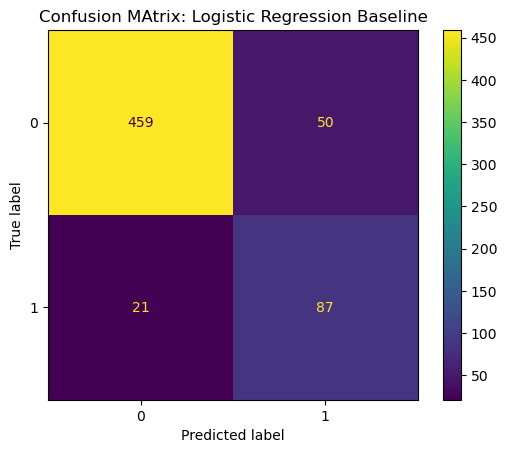

In [31]:
log_reg_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

log_reg_baseline_results = evaluate_model_cv(
    "Logistic Regression Baseline",
    log_reg_baseline,
    X_model,
    y,
    cv
)

### Logistic Regression

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Logistic Regression parameters:
{'model__C': 0.1, 'model__penalty': 'l1'}
Best CV Balanced Log loss: 0.39358194630331783
Tuned Logistic Regression
Accuracy: 0.8687
Log Loss: 0.4050
Balanced Log Loss: 0.3939

Classifciation Report
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       509
           1       0.59      0.81      0.68       108

    accuracy                           0.87       617
   macro avg       0.77      0.84      0.80       617
weighted avg       0.89      0.87      0.88       617



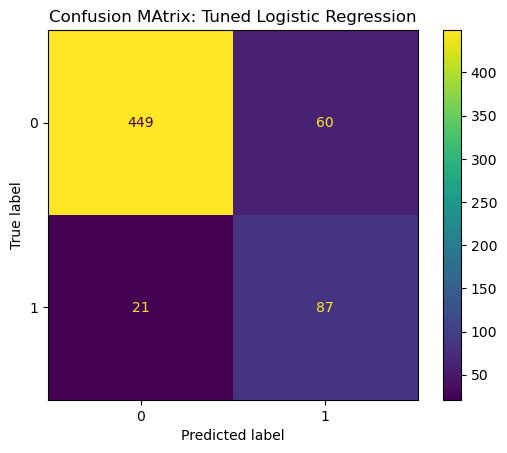

In [32]:
#LogReg model

log_reg_tune = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

if FAST_MODE:
    log_reg_param_grid = {
        "model__C": [0.01, 0.1, 1],
        "model__penalty": ["l1", "l2"]
    }
else:
    log_reg_param_grid = {
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__penalty": ["l1", "l2"]
    }

log_reg_grid = GridSearchCV(
    estimator=log_reg_tune,
    param_grid=log_reg_param_grid,
    scoring=negative_balanced_log_loss_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

log_reg_grid.fit(X_model, y)

print("Best Logistic Regression parameters:")
print(log_reg_grid.best_params_)
print("Best CV Balanced Log loss:", -log_reg_grid.best_score_)

best_log_reg = log_reg_grid.best_estimator_

log_reg_tuned_results = evaluate_model_cv(
    "Tuned Logistic Regression",
    best_log_reg,
    X_model,
    y,
    cv
)

### Support Vector Machine (SVM)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Linear SVM Parameters:
{'model__C': 0.01}
Best CV Balanced Log Loss: 0.5978003775363694
Tuned Linear SVM
Accuracy: 0.8898
Log Loss: 0.3218
Balanced Log Loss: 0.6001

Classifciation Report
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       509
           1       0.78      0.52      0.62       108

    accuracy                           0.89       617
   macro avg       0.84      0.74      0.78       617
weighted avg       0.88      0.89      0.88       617



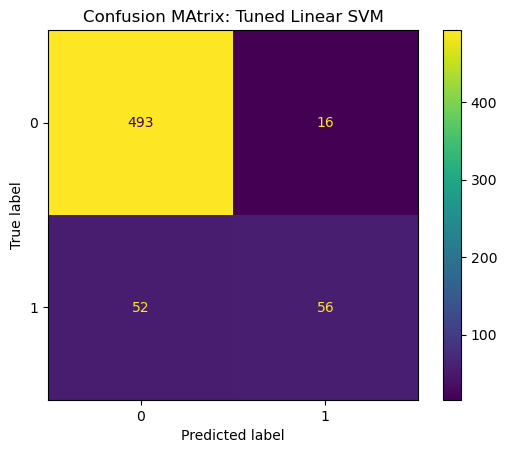

In [33]:
#Linear SVM model
linear_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

if FAST_MODE:
    linear_svm_param_grid = {
        "model__C": [0.01, 0.1, 1]
    }
else:
    linear_svm_param_grid = {
        "model__C": [0.001, 0.01, 0.1, 1, 10]
    }  

linear_svm_grid = GridSearchCV(
    estimator=linear_svm,
    param_grid=linear_svm_param_grid,
    scoring=negative_balanced_log_loss_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

linear_svm_grid.fit(X_model, y)

print("Best Linear SVM Parameters:")
print(linear_svm_grid.best_params_)
print("Best CV Balanced Log Loss:", -linear_svm_grid.best_score_)

best_linear_svm = linear_svm_grid.best_estimator_

linear_svm_results = evaluate_model_cv(
    "Tuned Linear SVM",
    best_linear_svm,
    X_model,
    y,
    cv
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best RBF SVM Parameters:
{'model__C': 10, 'model__gamma': 'scale'}
Best CV Balanced Log Loss: 0.44135094538252995
Tuned RBF SVM
Accuracy: 0.8995
Log Loss: 0.2355
Balanced Log Loss: 0.4425

Classifciation Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       509
           1       0.79      0.58      0.67       108

    accuracy                           0.90       617
   macro avg       0.85      0.77      0.81       617
weighted avg       0.89      0.90      0.89       617



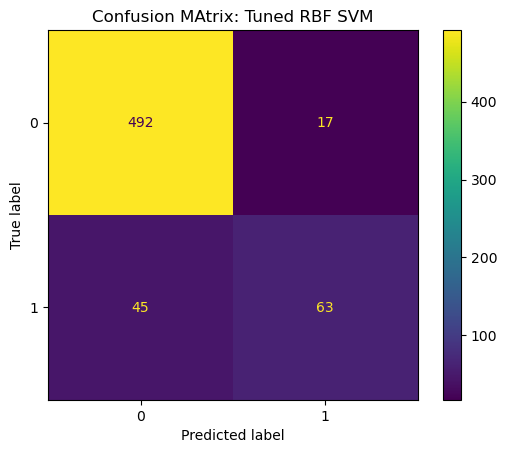

In [34]:
#RBF MODEL

rbf_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

if FAST_MODE:
    rbf_svm_param_grid = {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01]
    }
else:
    rbf_svm_param_grid = {
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", 0.001, 0.01, 0.1]
    }  

rbf_svm_grid = GridSearchCV(
    estimator=rbf_svm,
    param_grid=rbf_svm_param_grid,
    scoring=negative_balanced_log_loss_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rbf_svm_grid.fit(X_model, y)

print("Best RBF SVM Parameters:")
print(rbf_svm_grid.best_params_)
print("Best CV Balanced Log Loss:", -rbf_svm_grid.best_score_)

best_rbf_svm = rbf_svm_grid.best_estimator_

rbf_svm_results = evaluate_model_cv(
    "Tuned RBF SVM",
    best_rbf_svm,
    X_model,
    y,
    cv
)

### Random Forest

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest Parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV Balanced Log Loss: 0.4174970378066537
Tuned Random Forest
Accuracy: 0.9335
Log Loss: 0.2768
Balanced Log Loss: 0.4174

Classifciation Report
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       509
           1       0.84      0.77      0.80       108

    accuracy                           0.93       617
   macro avg       0.90      0.87      0.88       617
weighted avg       0.93      0.93      0.93       617



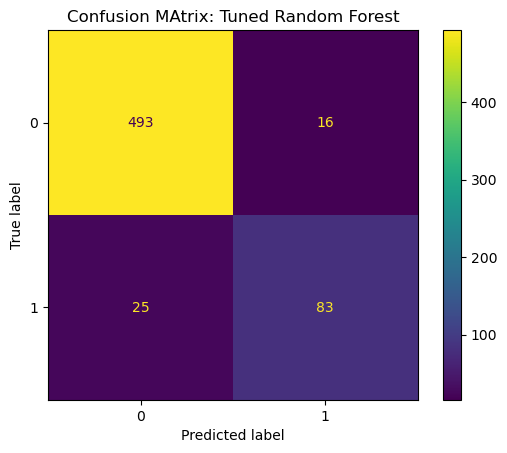

In [35]:
#Random Forest Model

random_forest = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

if FAST_MODE:
    rf_param_grid = {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 5, 8],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt"]
    }
else:
    rf_param_grid = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 3, 5, 8, 12],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    }

rf_grid = GridSearchCV(
    estimator=random_forest,
    param_grid=rf_param_grid,
    scoring=negative_balanced_log_loss_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_model, y)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)
print("Best CV Balanced Log Loss:", -rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

rf_results = evaluate_model_cv(
    "Tuned Random Forest",
    best_rf,
    X_model,
    y,
    cv
)

## Saving Results

In this section, we save model predictions and outputs for later use in ensemble models and final evaluation.

In [ ]:
#Comparison with Balanced Log loss

all_results = [
    log_reg_baseline_results,
    log_reg_tuned_results,
    linear_svm_results,
    rbf_svm_results,
    rf_results
]

comparison_df = pd.DataFrame([
    {
        "Model": result["model_name"],
        "Accuracy": result["accuracy"],
        "Recall Class 1": result["recall_class1"],
        "F1 Class 1": result["f1_class1"],
        "Log Loss": result["log_loss"]
    }
    for result in all_results
]).sort_values("Log Loss")

,Model,Accuracy,Recall Class 1,F1 Class 1,Log Loss
3,Tuned RBF SVM,0.899514,0.583333,0.670213,0.235492
4,Tuned Random Forest,0.933549,0.768519,0.801932,0.276801
2,Tuned Linear SVM,0.889789,0.518519,0.622222,0.321816
1,Tuned Logistic Regression,0.868720,0.805556,0.682353,0.405039
0,Logistic Regression Baseline,0.884927,0.805556,0.710204,0.430689


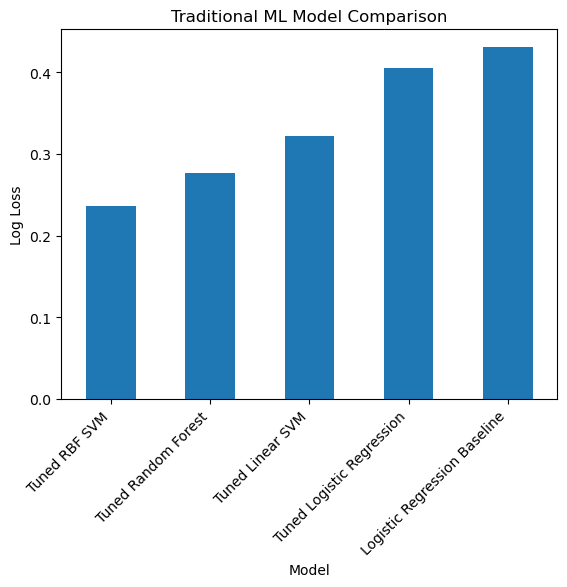

In [38]:
comparison_df.set_index("Model")["Log Loss"].sort_values().plot(kind="bar")
plt.title("Traditional ML Model Comparison")
plt.ylabel("Log Loss")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.show()

In [39]:
#Selelcts the Lowest loss model with is the best for this

model_lookup = {
    "Logistic Regression Baseline": log_reg_baseline,
    "Tuned Logistic Regression": best_log_reg,
    "Tuned Linear SVM": best_linear_svm,
    "Tuned RBF SVM": best_rbf_svm,
    "Tuned Random Forest": best_rf
}

best_model_name = comparison_df.iloc[0]["Model"]
best_model = model_lookup[best_model_name]

print("Best Traditional ML Model:", best_model_name)
print(comparison_df.iloc[0])

Best Traditional ML Model: Tuned RBF SVM
Model             Tuned RBF SVM
Accuracy               0.899514
Recall Class 1         0.583333
F1 Class 1             0.670213
Log Loss               0.235492
Name: 3, dtype: object


In [43]:
#Predictos probabilites for the test set
ensemble_oof = pd.DataFrame({
    "Id": train["Id"],
    "Class": y
})

for result in all_results:
    name = result["model_name"].replace(" ","_").replace("-","_").lower()
    ensemble_oof[f"{name}_class_0"] = result["oof_proba"][:, 0]
    ensemble_oof[f"{name}_class_1"] = result["oof_proba"][:, 1]

REPORTS_DIR = Path("../Reports")
REPORTS_DIR.mkdir(exist_ok=True)

ensemble_oof.to_csv(REPORTS_DIR / "traditional_oof_predictions.csv", index=False)

## Final Model Training

After evaluating all models, the best-performing model is retrained on the full dataset.

This ensures the model utilizes all available data before generating final predictions.

In [44]:
best_model.fit(X_model, y)

test_proba = best_model.predict_proba(test_model)

traditional_test_predictions = pd.DataFrame({
    "Id": test_ids,
    "class_0": test_proba[:, 0],
    "class_1": test_proba[:, 1]
})

final_predictions = best_model.predict_proba(X_model)
print("Final model trained on full dataset.")

traditional_test_predictions.to_csv("traditional_test_predictions.csv", index=False)

traditional_test_predictions

Final model trained on full dataset.


,Id,class_0,class_1
0,00eed32682bb,0.805805,0.194195
1,010ebe33f668,0.805805,0.194195
2,02fa521e1838,0.805805,0.194195
3,040e15f562a2,0.805805,0.194195
4,046e85c7cc7f,0.805805,0.194195


## Final Output

The trained models generate probability predictions for each class, which are used for evaluation and comparison across different approaches.

Final model outputs are saved for further analysis and integration with other models in the project.